YCB-Video Model Comparison — Week 5

Overview

This notebook compares four classical machine learning models on the YCB-Video BOP19 dataset:

* Logistic Regression
* Decision Tree
* Random Forest
* Gradient Boosting

The models use the same handcrafted RGB and bounding-box features for a fair comparison.

Objectives

* Implement and compare classical classification models.
* Analyze Decision Trees, Random Forests, and Gradient Boosting.
* Evaluate performance using both random frame-level and scene-level splits.
* Analyze confusion matrices, feature importance, and model failures.
* Investigate cross-scene generalization.

Neural networks are excluded from this week’s work.

Main Features

* Mean and standard deviation of RGB channels
* Bounding-box width and height
* Aspect ratio
* Area ratio

The target variable is obj_id.

In [2]:
# Cell 2 — Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
# Cell 3 — Locate YCB-Video Dataset

PROJECT_ROOT = Path("../..")
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Data directory exists: {DATA_DIR.exists()}")

if DATA_DIR.exists():
    print("\nFiles and directories inside data/:\n")

    for item in sorted(DATA_DIR.iterdir()):
        print(f"- {item.name}")

    zip_file = DATA_DIR / "ycbv_test_bop19.zip"

    print(f"\nZIP file exists: {zip_file.exists()}")

else:
    print("\nData directory was not found.")

Project root: /Users/mac/Documents/MLInternship_week5
Data directory: /Users/mac/Documents/MLInternship_week5/data
Data directory exists: True

Files and directories inside data/:

- ycbv
- ycbv_test_bop19.zip

ZIP file exists: True


In [9]:
# Cell 4 — Inspect Dataset Structure

DATASET_DIR = DATA_DIR / "ycbv"

print(f"Dataset directory: {DATASET_DIR.resolve()}")
print(f"Dataset directory exists: {DATASET_DIR.exists()}")

if DATASET_DIR.exists():
    print("\nContents of ycbv/:\n")

    for item in sorted(DATASET_DIR.iterdir()):
        item_type = "DIR " if item.is_dir() else "FILE"
        print(f"[{item_type}] {item.name}")

else:
    print("\nYCB-Video dataset directory was not found.")

Dataset directory: /Users/mac/Documents/MLInternship_week5/data/ycbv
Dataset directory exists: True

Contents of ycbv/:

[DIR ] test
[FILE] ycbv_test_bop19.zip


In [10]:
# Cell 5 — Inspect Test Scenes

TEST_DIR = DATASET_DIR / "test"

print(f"Test directory: {TEST_DIR.resolve()}")
print(f"Test directory exists: {TEST_DIR.exists()}")

if TEST_DIR.exists():
    scenes = sorted(
        path.name
        for path in TEST_DIR.iterdir()
        if path.is_dir()
    )

    print(f"\nNumber of scenes: {len(scenes)}")
    print("Scenes:")

    for scene in scenes:
        print(f"- {scene}")

else:
    print("\nTest directory was not found.")

Test directory: /Users/mac/Documents/MLInternship_week5/data/ycbv/test
Test directory exists: True

Number of scenes: 12
Scenes:
- 000048
- 000049
- 000050
- 000051
- 000052
- 000053
- 000054
- 000055
- 000056
- 000057
- 000058
- 000059


In [11]:
# Cell 6 — Inspect a Sample Scene

SAMPLE_SCENE = TEST_DIR / "000048"

print(f"Sample scene: {SAMPLE_SCENE.resolve()}")
print(f"Scene exists: {SAMPLE_SCENE.exists()}")

if SAMPLE_SCENE.exists():
    scene_contents = sorted(SAMPLE_SCENE.iterdir())

    print(f"\nNumber of items: {len(scene_contents)}")
    print("\nScene contents:")

    for item in scene_contents:
        item_type = "DIR " if item.is_dir() else "FILE"
        print(f"[{item_type}] {item.name}")

else:
    print("\nSample scene was not found.")

Sample scene: /Users/mac/Documents/MLInternship_week5/data/ycbv/test/000048
Scene exists: True

Number of items: 7

Scene contents:
[DIR ] depth
[DIR ] mask
[DIR ] mask_visib
[DIR ] rgb
[FILE] scene_camera.json
[FILE] scene_gt.json
[FILE] scene_gt_info.json


In [12]:
# Cell 7 — Inspect RGB and Annotation Files

RGB_DIR = SAMPLE_SCENE / "rgb"
GT_FILE = SAMPLE_SCENE / "scene_gt.json"
GT_INFO_FILE = SAMPLE_SCENE / "scene_gt_info.json"

print(f"RGB directory: {RGB_DIR.resolve()}")
print(f"RGB directory exists: {RGB_DIR.exists()}")

if RGB_DIR.exists():
    rgb_files = sorted(RGB_DIR.iterdir())

    print(f"\nNumber of RGB images: {len(rgb_files)}")
    print("First 5 RGB files:")

    for file in rgb_files[:5]:
        print(f"- {file.name}")

print(f"\nGround-truth file exists: {GT_FILE.exists()}")
print(f"Ground-truth info file exists: {GT_INFO_FILE.exists()}")

RGB directory: /Users/mac/Documents/MLInternship_week5/data/ycbv/test/000048/rgb
RGB directory exists: True

Number of RGB images: 75
First 5 RGB files:
- 000001.png
- 000036.png
- 000047.png
- 000083.png
- 000112.png

Ground-truth file exists: True
Ground-truth info file exists: True


In [13]:
# Cell 8 — Load Ground-Truth Annotations

import json

with open(GT_FILE, "r") as f:
    scene_gt = json.load(f)

with open(GT_INFO_FILE, "r") as f:
    scene_gt_info = json.load(f)

print(f"Number of frames in scene_gt: {len(scene_gt)}")
print(f"Number of frames in scene_gt_info: {len(scene_gt_info)}")

# Inspect the first frame
first_frame_id = sorted(scene_gt.keys(), key=int)[0]

print(f"\nFirst frame ID: {first_frame_id}")

print("\nGround-truth objects:")
print(scene_gt[first_frame_id])

print("\nGround-truth info:")
print(scene_gt_info[first_frame_id])

Number of frames in scene_gt: 75
Number of frames in scene_gt_info: 75

First frame ID: 1

Ground-truth objects:
[{'cam_R_m2c': [0.6155426282490462, -0.7872002747152219, -0.03771988906432555, -0.19894986552077276, -0.10889926681888931, -0.9739401059834828, 0.7625789371251613, 0.6070060649389416, -0.22364550906920733], 'cam_t_m2c': [-31.677025422232273, -17.368816807616497, 865.056765056294], 'obj_id': 1}, {'cam_R_m2c': [-0.888800154374123, 0.45524946687574985, -0.05275501966907288, 0.15161264602174085, 0.18344755196788856, -0.9712669209190921, -0.4324911950904046, -0.8712604167821704, -0.2320697374100931], 'cam_t_m2c': [19.826959191155, 56.52491050704691, 810.7227026810766], 'obj_id': 6}, {'cam_R_m2c': [0.800270328363595, -0.5984833728683278, -0.03721742358490441, -0.16673638817023093, -0.16247691893389601, -0.97252257766676, 0.5759917033378716, 0.7844862673094515, -0.22981459219802255], 'cam_t_m2c': [-23.310093543898354, -112.62940453072957, 848.1679482820954], 'obj_id': 14}, {'cam_R_

In [14]:
# Cell 9 — Inspect One Annotated Object

frame_id = first_frame_id
object_index = 0

object_annotation = scene_gt[frame_id][object_index]
object_info = scene_gt_info[frame_id][object_index]

obj_id = object_annotation["obj_id"]
bbox = object_info["bbox_obj"]
visibility = object_info["visib_fract"]

rgb_path = RGB_DIR / f"{int(frame_id):06d}.png"

print(f"Frame ID: {frame_id}")
print(f"RGB file: {rgb_path.name}")
print(f"RGB file exists: {rgb_path.exists()}")
print(f"Object ID: {obj_id}")
print(f"Bounding box [x, y, width, height]: {bbox}")
print(f"Visibility fraction: {visibility:.4f}")

Frame ID: 1
RGB file: 000001.png
RGB file exists: True
Object ID: 1
Bounding box [x, y, width, height]: [206, 126, 132, 194]
Visibility fraction: 0.9351


In [15]:
# Cell 10 — Extract Features from One Object

image = Image.open(rgb_path).convert("RGB")
image_array = np.array(image)

image_height, image_width = image_array.shape[:2]

x, y, bbox_width, bbox_height = bbox

# Crop the bounding box
crop = image_array[
    y:y + bbox_height,
    x:x + bbox_width
]

# RGB statistics
mean_r, mean_g, mean_b = crop.mean(axis=(0, 1))
std_r, std_g, std_b = crop.std(axis=(0, 1))

# Geometric features
aspect_ratio = bbox_width / bbox_height
area_ratio = (bbox_width * bbox_height) / (image_width * image_height)

features = {
    "mean_r": mean_r,
    "mean_g": mean_g,
    "mean_b": mean_b,
    "std_r": std_r,
    "std_g": std_g,
    "std_b": std_b,
    "bbox_width": bbox_width,
    "bbox_height": bbox_height,
    "aspect_ratio": aspect_ratio,
    "area_ratio": area_ratio,
}

print("Image size:", image_array.shape)
print("Crop size:", crop.shape)

print("\nExtracted features:")
for name, value in features.items():
    print(f"{name}: {value:.4f}")

print(f"\nTarget (object ID): {obj_id}")

Image size: (480, 640, 3)
Crop size: (194, 132, 3)

Extracted features:
mean_r: 75.2920
mean_g: 47.4756
mean_b: 78.4779
std_r: 72.3971
std_g: 62.4780
std_b: 61.0667
bbox_width: 132.0000
bbox_height: 194.0000
aspect_ratio: 0.6804
area_ratio: 0.0834

Target (object ID): 1


In [16]:
# Cell 11 — Build Feature Dataset for One Scene

samples = []

for frame_id in sorted(scene_gt.keys(), key=int):
    rgb_path = RGB_DIR / f"{int(frame_id):06d}.png"

    # Skip frames whose RGB image is missing
    if not rgb_path.exists():
        continue

    image = Image.open(rgb_path).convert("RGB")
    image_array = np.array(image)

    image_height, image_width = image_array.shape[:2]

    objects = scene_gt[frame_id]
    objects_info = scene_gt_info[frame_id]

    for object_annotation, object_info in zip(objects, objects_info):

        obj_id = object_annotation["obj_id"]

        x, y, bbox_width, bbox_height = object_info["bbox_obj"]

        # Crop the bounding box
        crop = image_array[
            y:y + bbox_height,
            x:x + bbox_width
        ]

        # Skip invalid crops
        if crop.size == 0:
            continue

        # RGB statistics
        mean_r, mean_g, mean_b = crop.mean(axis=(0, 1))
        std_r, std_g, std_b = crop.std(axis=(0, 1))

        # Geometric features
        aspect_ratio = bbox_width / bbox_height
        area_ratio = (
            bbox_width * bbox_height
        ) / (image_width * image_height)

        samples.append({
            "scene_id": SAMPLE_SCENE.name,
            "frame_id": int(frame_id),
            "obj_id": obj_id,
            "mean_r": mean_r,
            "mean_g": mean_g,
            "mean_b": mean_b,
            "std_r": std_r,
            "std_g": std_g,
            "std_b": std_b,
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
            "aspect_ratio": aspect_ratio,
            "area_ratio": area_ratio,
        })

scene_df = pd.DataFrame(samples)

print(f"Number of samples: {len(scene_df)}")
print(f"Number of features: {len(scene_df.columns) - 3}")

print("\nClass distribution:")
print(scene_df["obj_id"].value_counts().sort_index())

print("\nFirst 5 samples:")
display(scene_df.head())

Number of samples: 375
Number of features: 10

Class distribution:
obj_id
1     75
6     75
14    75
19    75
20    75
Name: count, dtype: int64

First 5 samples:


,scene_id,frame_id,obj_id,mean_r,mean_g,mean_b,std_r,std_g,std_b,bbox_width,bbox_height,aspect_ratio,area_ratio
0,000048,1,1,75.292018,47.475633,78.477898,72.397053,62.478017,61.066657,132,194,0.680412,0.083359
1,000048,1,6,75.327666,62.274584,92.078645,64.072237,61.194563,62.344441,112,73,1.534247,0.026615
2,000048,1,14,118.214133,40.600220,45.428202,60.051999,69.501648,65.050489,137,113,1.212389,0.050394
3,000048,1,19,133.172300,114.710798,129.490193,97.115722,98.915299,99.049934,90,213,0.422535,0.062402
4,000048,1,20,52.762742,36.079485,49.287481,62.550437,56.548765,67.512637,349,127,2.748031,0.144281


In [17]:
# Cell 12 — Prepare Features and Train/Test Split

FEATURE_COLUMNS = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "bbox_width",
    "bbox_height",
    "aspect_ratio",
    "area_ratio",
]

TARGET_COLUMN = "obj_id"

X = scene_df[FEATURE_COLUMNS]
y = scene_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Feature matrix shape:")
print(f"X: {X.shape}")

print("\nTarget shape:")
print(f"y: {y.shape}")

print("\nTrain/Test split:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Feature matrix shape:
X: (375, 10)

Target shape:
y: (375,)

Train/Test split:
X_train: (300, 10)
X_test:  (75, 10)
y_train: (300,)
y_test:  (75,)

Training class distribution:
obj_id
1     60
6     60
14    60
19    60
20    60
Name: count, dtype: int64

Test class distribution:
obj_id
1     15
6     15
14    15
19    15
20    15
Name: count, dtype: int64


In [18]:
# Cell 13 — Train Baseline Decision Tree

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully.")
print(f"Tree depth: {decision_tree.get_depth()}")
print(f"Number of leaves: {decision_tree.get_n_leaves()}")

Decision Tree trained successfully.
Tree depth: 3
Number of leaves: 5


In [19]:
# Cell 14 — Evaluate Decision Tree

y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")

print("\nClassification Report — Test Set")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

Training accuracy: 1.0000
Test accuracy:     1.0000

Classification Report — Test Set
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        15
          19       1.00      1.00      1.00        15
          20       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



Confusion Matrix:
[[15  0  0  0  0]
 [ 0 15  0  0  0]
 [ 0  0 15  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 15]]


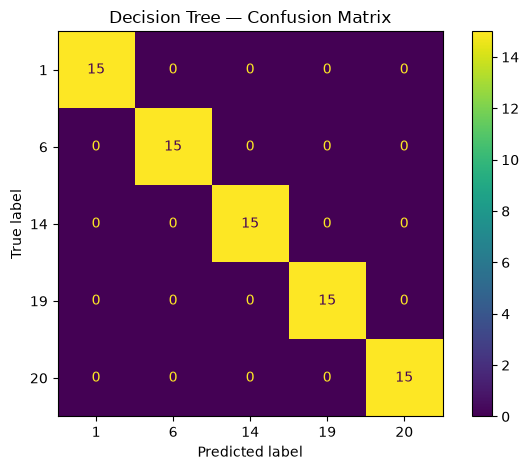

In [20]:
# Cell 15 — Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=decision_tree.classes_
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=decision_tree.classes_
)

disp.plot()
plt.title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

Feature importance:


,feature,importance
0,aspect_ratio,0.50
1,bbox_width,0.25
2,bbox_height,0.25
3,mean_r,0.00
4,mean_g,0.00
5,mean_b,0.00
6,std_b,0.00
7,std_g,0.00
8,std_r,0.00
9,area_ratio,0.00


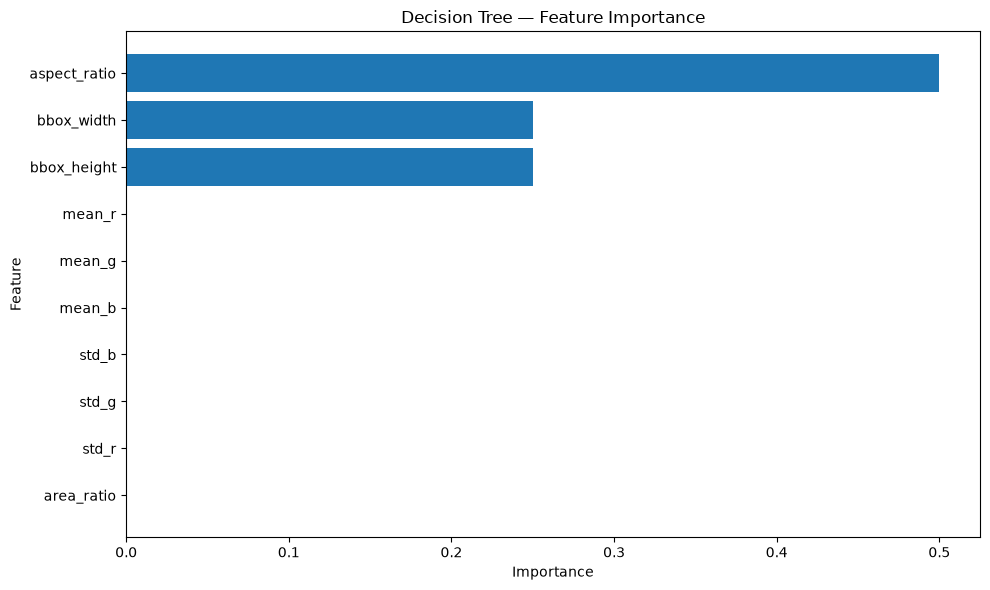

In [21]:
# Cell 16 — Feature Importance

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": decision_tree.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("Feature importance:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree — Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [22]:
# Cell 17 — Inspect the Decision Tree Structure

from sklearn.tree import export_text

tree_rules = export_text(
    decision_tree,
    feature_names=FEATURE_COLUMNS
)

print(tree_rules)

|--- aspect_ratio <= 0.65
|   |--- class: 19
|--- aspect_ratio >  0.65
|   |--- aspect_ratio <= 1.37
|   |   |--- bbox_height <= 136.00
|   |   |   |--- class: 14
|   |   |--- bbox_height >  136.00
|   |   |   |--- class: 1
|   |--- aspect_ratio >  1.37
|   |   |--- bbox_width <= 157.00
|   |   |   |--- class: 6
|   |   |--- bbox_width >  157.00
|   |   |   |--- class: 20



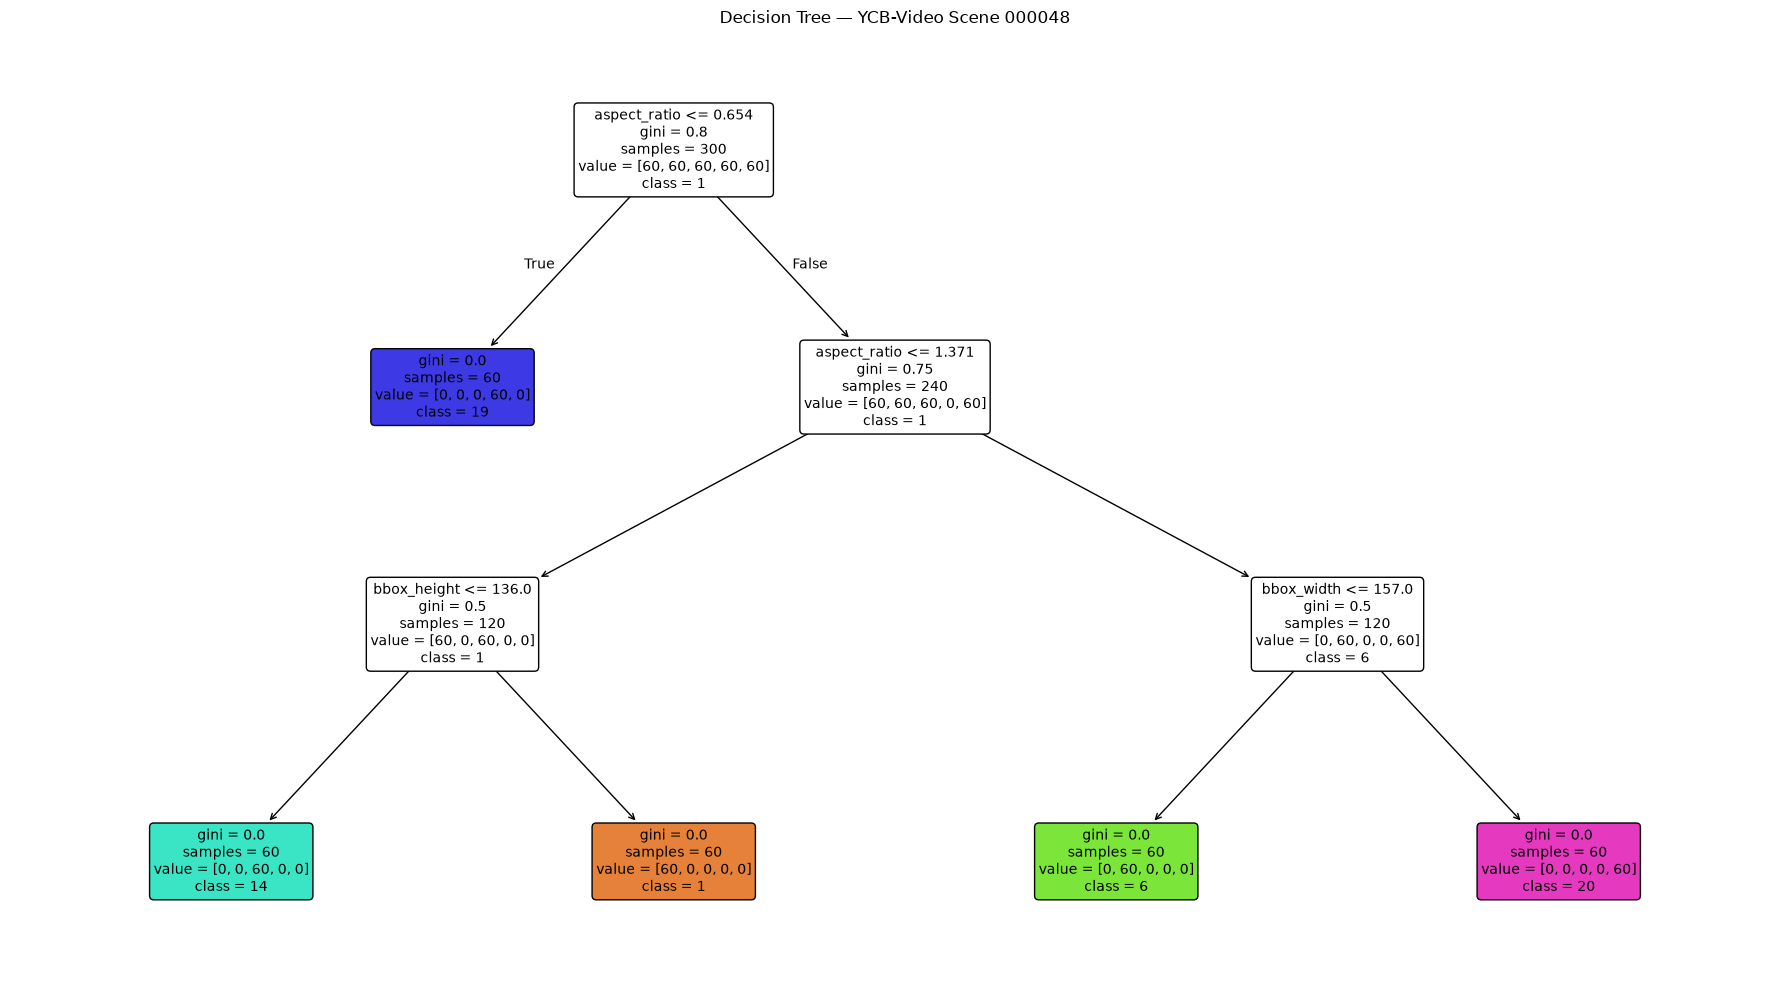

In [23]:
# Cell 18 — Visualize Decision Tree

from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    decision_tree,
    feature_names=FEATURE_COLUMNS,
    class_names=[str(class_id) for class_id in decision_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree — YCB-Video Scene 000048")
plt.tight_layout()
plt.show()

In [24]:
# Cell 19 — Effect of Tree Depth

depths = range(1, 11)

depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "n_leaves": tree.get_n_leaves(),
    })

depth_results_df = pd.DataFrame(depth_results)

print("Decision Tree performance at different depths:")
display(depth_results_df)

Decision Tree performance at different depths:


,max_depth,train_accuracy,test_accuracy,n_leaves
0,1,0.4,0.4,2
1,2,0.6,0.6,3
2,3,1.0,1.0,5
3,4,1.0,1.0,5
4,5,1.0,1.0,5
5,6,1.0,1.0,5
6,7,1.0,1.0,5
7,8,1.0,1.0,5
8,9,1.0,1.0,5
9,10,1.0,1.0,5


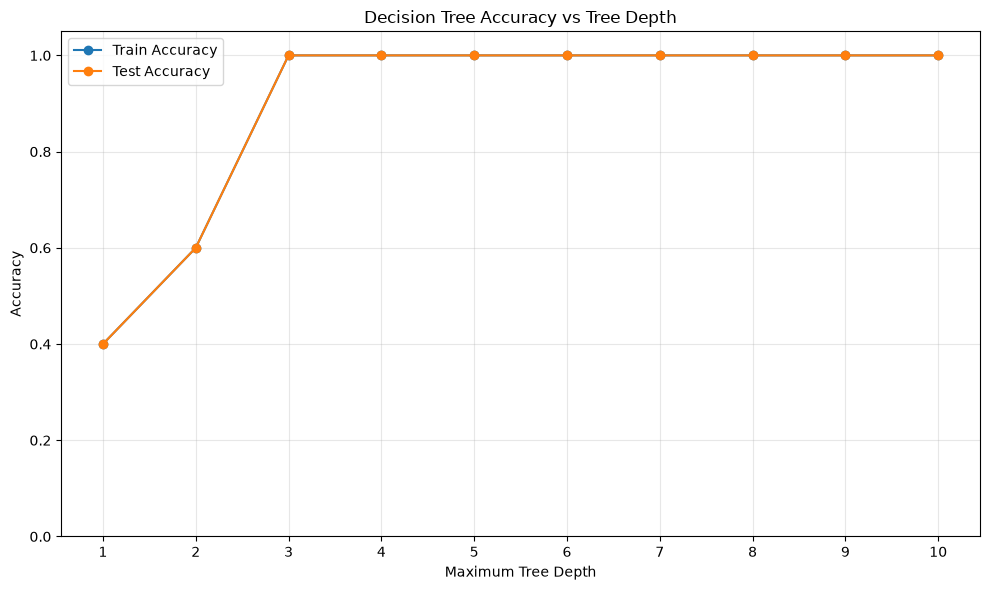

In [25]:
# Cell 20 — Accuracy vs Tree Depth

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results_df["max_depth"],
    depth_results_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    depth_results_df["max_depth"],
    depth_results_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Tree Depth")
plt.xticks(depth_results_df["max_depth"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:


depth_analysis = depth_results_df.copy()

# Add train-test accuracy gap
depth_analysis["accuracy_gap"] = (
    depth_analysis["train_accuracy"]
    - depth_analysis["test_accuracy"]
)

# Add error rates
depth_analysis["train_error"] = (
    1 - depth_analysis["train_accuracy"]
)

depth_analysis["test_error"] = (
    1 - depth_analysis["test_accuracy"]
)

print("Numerical analysis of Decision Tree depth:\n")
display(depth_analysis)

Numerical analysis of Decision Tree depth:



,max_depth,train_accuracy,test_accuracy,n_leaves,accuracy_gap,train_error,test_error
0,1,0.4,0.4,2,0.0,0.6,0.6
1,2,0.6,0.6,3,0.0,0.4,0.4
2,3,1.0,1.0,5,0.0,0.0,0.0
3,4,1.0,1.0,5,0.0,0.0,0.0
4,5,1.0,1.0,5,0.0,0.0,0.0
5,6,1.0,1.0,5,0.0,0.0,0.0
6,7,1.0,1.0,5,0.0,0.0,0.0
7,8,1.0,1.0,5,0.0,0.0,0.0
8,9,1.0,1.0,5,0.0,0.0,0.0
9,10,1.0,1.0,5,0.0,0.0,0.0


In [27]:
# Cell 21 — Effect of min_samples_leaf

leaf_sizes = [1, 2, 5, 10, 15, 20, 30]

leaf_results = []

for min_leaf in leaf_sizes:
    tree = DecisionTreeClassifier(
        random_state=42,
        min_samples_leaf=min_leaf
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    leaf_results.append({
        "min_samples_leaf": min_leaf,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc,
        "tree_depth": tree.get_depth(),
        "n_leaves": tree.get_n_leaves(),
    })

leaf_results_df = pd.DataFrame(leaf_results)

print("Decision Tree performance with different min_samples_leaf values:\n")
display(leaf_results_df)

Decision Tree performance with different min_samples_leaf values:



,min_samples_leaf,train_accuracy,test_accuracy,accuracy_gap,tree_depth,n_leaves
0,1,1.0,1.0,0.0,3,5
1,2,1.0,1.0,0.0,3,5
2,5,1.0,1.0,0.0,3,5
3,10,1.0,1.0,0.0,3,5
4,15,1.0,1.0,0.0,3,5
5,20,1.0,1.0,0.0,3,5
6,30,1.0,1.0,0.0,3,5


In [28]:
# Cell 22 — Final Decision Tree Baseline

dt_baseline = pd.DataFrame({
    "model": ["Decision Tree"],
    "train_accuracy": [accuracy_score(y_train, decision_tree.predict(X_train))],
    "test_accuracy": [accuracy_score(y_test, decision_tree.predict(X_test))],
    "tree_depth": [decision_tree.get_depth()],
    "n_leaves": [decision_tree.get_n_leaves()],
})

print("Decision Tree Baseline:\n")
display(dt_baseline)

Decision Tree Baseline:



,model,train_accuracy,test_accuracy,tree_depth,n_leaves
0,Decision Tree,1.0,1.0,3,5


In [29]:
# Cell 23 — Random Forest Import

from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [30]:
# Cell 24 — Train Baseline Random Forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully.")
print(f"Number of trees: {len(random_forest.estimators_)}")

Random Forest trained successfully.
Number of trees: 100


In [31]:
# Cell 25 — Evaluate Random Forest

rf_train_pred = random_forest.predict(X_train)
rf_test_pred = random_forest.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print(f"Training accuracy: {rf_train_accuracy:.4f}")
print(f"Test accuracy:     {rf_test_accuracy:.4f}")

print("\nClassification Report — Test Set")
print(
    classification_report(
        y_test,
        rf_test_pred,
        zero_division=0
    )
)

Training accuracy: 1.0000
Test accuracy:     1.0000

Classification Report — Test Set
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        15
          19       1.00      1.00      1.00        15
          20       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [32]:
# Cell 26 — Inspect Individual Trees

tree_statistics = []

for i, tree in enumerate(random_forest.estimators_):
    tree_statistics.append({
        "tree_id": i + 1,
        "depth": tree.get_depth(),
        "n_leaves": tree.get_n_leaves(),
    })

rf_tree_stats = pd.DataFrame(tree_statistics)

print("Random Forest — Individual Tree Statistics:\n")
display(rf_tree_stats.describe())

print("\nFirst 10 trees:")
display(rf_tree_stats.head(10))

Random Forest — Individual Tree Statistics:



,tree_id,depth,n_leaves
count,100.000000,100.000000,100.000000
mean,50.500000,5.110000,8.330000
std,29.011492,1.230053,2.711945
min,1.000000,3.000000,5.000000
25%,25.750000,4.000000,6.000000
50%,50.500000,5.000000,8.000000
75%,75.250000,6.000000,11.000000
max,100.000000,8.000000,15.000000



First 10 trees:


,tree_id,depth,n_leaves
0,1,5,9
1,2,7,10
2,3,5,8
3,4,4,9
4,5,5,7
5,6,7,8
6,7,5,12
7,8,6,8
8,9,5,6
9,10,4,5


In [33]:
# Cell 27 — Random Forest Feature Importance

rf_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": random_forest.feature_importances_,
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance:\n")
display(rf_feature_importance)

Random Forest Feature Importance:



,feature,importance
0,aspect_ratio,0.274453
1,bbox_height,0.225505
2,area_ratio,0.197709
3,bbox_width,0.152751
4,std_r,0.035911
5,mean_r,0.031016
6,std_b,0.030463
7,mean_g,0.019889
8,mean_b,0.018375
9,std_g,0.013929


In [34]:
# Cell 28 — Effect of Number of Trees

n_estimators_values = [1, 5, 10, 25, 50, 100, 200]

rf_results = []

for n_trees in n_estimators_values:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42
    )

    rf.fit(X_train, y_train)

    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    rf_results.append({
        "n_estimators": n_trees,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc,
    })

rf_results_df = pd.DataFrame(rf_results)

print("Random Forest performance with different numbers of trees:\n")
display(rf_results_df)

Random Forest performance with different numbers of trees:



,n_estimators,train_accuracy,test_accuracy,accuracy_gap
0,1,1.0,0.96,0.04
1,5,1.0,1.00,0.00
2,10,1.0,1.00,0.00
3,25,1.0,1.00,0.00
4,50,1.0,1.00,0.00
5,100,1.0,1.00,0.00
6,200,1.0,1.00,0.00


In [35]:
# Cell 29 — Out-of-Bag Evaluation

random_forest_oob = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

random_forest_oob.fit(X_train, y_train)

print("Random Forest with OOB evaluation")
print(f"Number of trees: {len(random_forest_oob.estimators_)}")
print(f"OOB score: {random_forest_oob.oob_score_:.4f}")

Random Forest with OOB evaluation
Number of trees: 100
OOB score: 1.0000


In [36]:
# Cell 30 — Random Forest Feature Randomness

max_features_values = [1, 2, 3, 5, 7, 10]

feature_randomness_results = []

for max_features in max_features_values:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=max_features,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    
    feature_randomness_results.append({
        "max_features": max_features,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc
    })

rf_feature_randomness_df = pd.DataFrame(feature_randomness_results)

display(rf_feature_randomness_df)

,max_features,train_accuracy,test_accuracy,accuracy_gap
0,1,1.0,1.0,0.0
1,2,1.0,1.0,0.0
2,3,1.0,1.0,0.0
3,5,1.0,1.0,0.0
4,7,1.0,1.0,0.0
5,10,1.0,1.0,0.0


In [37]:
# Cell 31 — Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

print("Gradient Boosting imported successfully.")

Gradient Boosting imported successfully.


In [38]:
# Cell 32 — Gradient Boosting Baseline

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")
print(f"Number of boosting stages: {gradient_boosting.n_estimators}")

Gradient Boosting trained successfully.
Number of boosting stages: 100


In [39]:
# Cell 33 — Gradient Boosting Evaluation

gb_train_pred = gradient_boosting.predict(X_train)
gb_test_pred = gradient_boosting.predict(X_test)

gb_train_accuracy = accuracy_score(y_train, gb_train_pred)
gb_test_accuracy = accuracy_score(y_test, gb_test_pred)

print(f"Training accuracy: {gb_train_accuracy:.4f}")
print(f"Test accuracy:     {gb_test_accuracy:.4f}")
print(f"Accuracy gap:      {gb_train_accuracy - gb_test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, gb_test_pred))

Training accuracy: 1.0000
Test accuracy:     1.0000
Accuracy gap:      0.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        15
          19       1.00      1.00      1.00        15
          20       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [40]:
# Cell 34 — Gradient Boosting: n_estimators Experiment

n_estimators_values = [10, 25, 50, 100, 150, 200]

gb_n_estimators_results = []

for n in n_estimators_values:
    gb = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    
    gb_n_estimators_results.append({
        "n_estimators": n,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc
    })

gb_n_estimators_df = pd.DataFrame(gb_n_estimators_results)

display(gb_n_estimators_df)

,n_estimators,train_accuracy,test_accuracy,accuracy_gap
0,10,1.0,1.0,0.0
1,25,1.0,1.0,0.0
2,50,1.0,1.0,0.0
3,100,1.0,1.0,0.0
4,150,1.0,1.0,0.0
5,200,1.0,1.0,0.0


In [41]:
# Cell 35 — Gradient Boosting: learning_rate Experiment

learning_rate_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

gb_learning_rate_results = []

for lr in learning_rate_values:
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    
    gb_learning_rate_results.append({
        "learning_rate": lr,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc
    })

gb_learning_rate_df = pd.DataFrame(gb_learning_rate_results)

display(gb_learning_rate_df)

,learning_rate,train_accuracy,test_accuracy,accuracy_gap
0,0.01,1.0,1.0,0.0
1,0.05,1.0,1.0,0.0
2,0.10,1.0,1.0,0.0
3,0.20,1.0,1.0,0.0
4,0.50,1.0,1.0,0.0
5,1.00,1.0,1.0,0.0


In [42]:
# Cell 36 — Gradient Boosting: max_depth Experiment

max_depth_values = [1, 2, 3, 4, 5]

gb_depth_results = []

for depth in max_depth_values:
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    
    gb.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    
    gb_depth_results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "accuracy_gap": train_acc - test_acc
    })

gb_depth_df = pd.DataFrame(gb_depth_results)

display(gb_depth_df)

,max_depth,train_accuracy,test_accuracy,accuracy_gap
0,1,1.0,1.0,0.0
1,2,1.0,1.0,0.0
2,3,1.0,1.0,0.0
3,4,1.0,1.0,0.0
4,5,1.0,1.0,0.0


In [43]:
# Cell 37 — Gradient Boosting Feature Importance

gb_feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": gradient_boosting.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(gb_feature_importance)

,feature,importance
8,aspect_ratio,5.774491e-01
9,area_ratio,1.331978e-01
5,std_b,9.462003e-02
7,bbox_height,8.991489e-02
3,std_r,6.616766e-02
6,bbox_width,2.067342e-02
0,mean_r,1.797710e-02
1,mean_g,6.800923e-17
2,mean_b,3.330034e-17
4,std_g,-2.870260e-18


In [44]:
# Cell 38 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [45]:
# Cell 39 — Logistic Regression Baseline

logistic_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_regression.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [46]:
# Cell 40 — Logistic Regression Evaluation

lr_train_pred = logistic_regression.predict(X_train)
lr_test_pred = logistic_regression.predict(X_test)

lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)

print(f"Training accuracy: {lr_train_accuracy:.4f}")
print(f"Test accuracy:     {lr_test_accuracy:.4f}")
print(f"Accuracy gap:      {lr_train_accuracy - lr_test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_test_pred))

Training accuracy: 1.0000
Test accuracy:     1.0000
Accuracy gap:      0.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        15
          14       1.00      1.00      1.00        15
          19       1.00      1.00      1.00        15
          20       1.00      1.00      1.00        15

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



In [47]:
# Cell 41 — Logistic Regression Coefficients

lr_classifier = logistic_regression.named_steps["classifier"]

lr_coefficients = pd.DataFrame(
    lr_classifier.coef_,
    columns=FEATURE_COLUMNS,
    index=lr_classifier.classes_
)

display(lr_coefficients)

,mean_r,mean_g,mean_b,std_r,std_g,std_b,bbox_width,bbox_height,aspect_ratio,area_ratio
1,0.433612,-2.046775,0.930651,0.353406,0.462797,-1.151039,-0.067549,0.176684,-1.150257,0.174717
6,-0.460516,0.632112,0.428859,-0.006775,-0.321855,-0.838500,-0.463961,-1.223664,0.879680,-1.086226
14,1.297385,-0.540578,-0.684868,-1.247741,0.597626,1.211921,0.155758,-0.652188,0.351811,-0.406604
19,-1.592015,2.191769,-0.045641,-0.268652,-0.431578,1.032729,-0.780522,2.021870,-1.090018,0.749978
20,0.321534,-0.236529,-0.629001,1.169762,-0.306990,-0.255111,1.156274,-0.322702,1.008785,0.568135


In [48]:
# Cell 42 — Initial Model Comparison

model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "train_accuracy": [
        lr_train_accuracy,
        accuracy_score(y_train, decision_tree.predict(X_train)),
        accuracy_score(y_train, random_forest.predict(X_train)),
        gb_train_accuracy
    ],
    "test_accuracy": [
        lr_test_accuracy,
        accuracy_score(y_test, decision_tree.predict(X_test)),
        accuracy_score(y_test, random_forest.predict(X_test)),
        gb_test_accuracy
    ]
})

model_comparison["accuracy_gap"] = (
    model_comparison["train_accuracy"]
    - model_comparison["test_accuracy"]
)

display(model_comparison)

,model,train_accuracy,test_accuracy,accuracy_gap
0,Logistic Regression,1.0,1.0,0.0
1,Decision Tree,1.0,1.0,0.0
2,Random Forest,1.0,1.0,0.0
3,Gradient Boosting,1.0,1.0,0.0


In [49]:
# Cell 43 — Detailed Model Metrics

model_predictions = {
    "Logistic Regression": lr_test_pred,
    "Decision Tree": decision_tree.predict(X_test),
    "Random Forest": random_forest.predict(X_test),
    "Gradient Boosting": gb_test_pred,
}

metrics_results = []

for model_name, predictions in model_predictions.items():
    metrics_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision_macro": __import__("sklearn.metrics", fromlist=["precision_score"]).precision_score(
            y_test, predictions, average="macro"
        ),
        "recall_macro": __import__("sklearn.metrics", fromlist=["recall_score"]).recall_score(
            y_test, predictions, average="macro"
        ),
        "f1_macro": __import__("sklearn.metrics", fromlist=["f1_score"]).f1_score(
            y_test, predictions, average="macro"
        ),
    })

detailed_metrics_df = pd.DataFrame(metrics_results)

display(detailed_metrics_df)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,Gradient Boosting,1.0,1.0,1.0,1.0


In [50]:
# Cell 44 — Model Complexity Comparison

complexity_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "n_features": [
        X_train.shape[1],
        X_train.shape[1],
        X_train.shape[1],
        X_train.shape[1]
    ],
    "n_parameters_or_components": [
        logistic_regression.named_steps["classifier"].coef_.size,
        decision_tree.get_n_leaves(),
        len(random_forest.estimators_),
        gradient_boosting.n_estimators
    ]
})

display(complexity_comparison)

,model,n_features,n_parameters_or_components
0,Logistic Regression,10,50
1,Decision Tree,10,5
2,Random Forest,10,100
3,Gradient Boosting,10,100


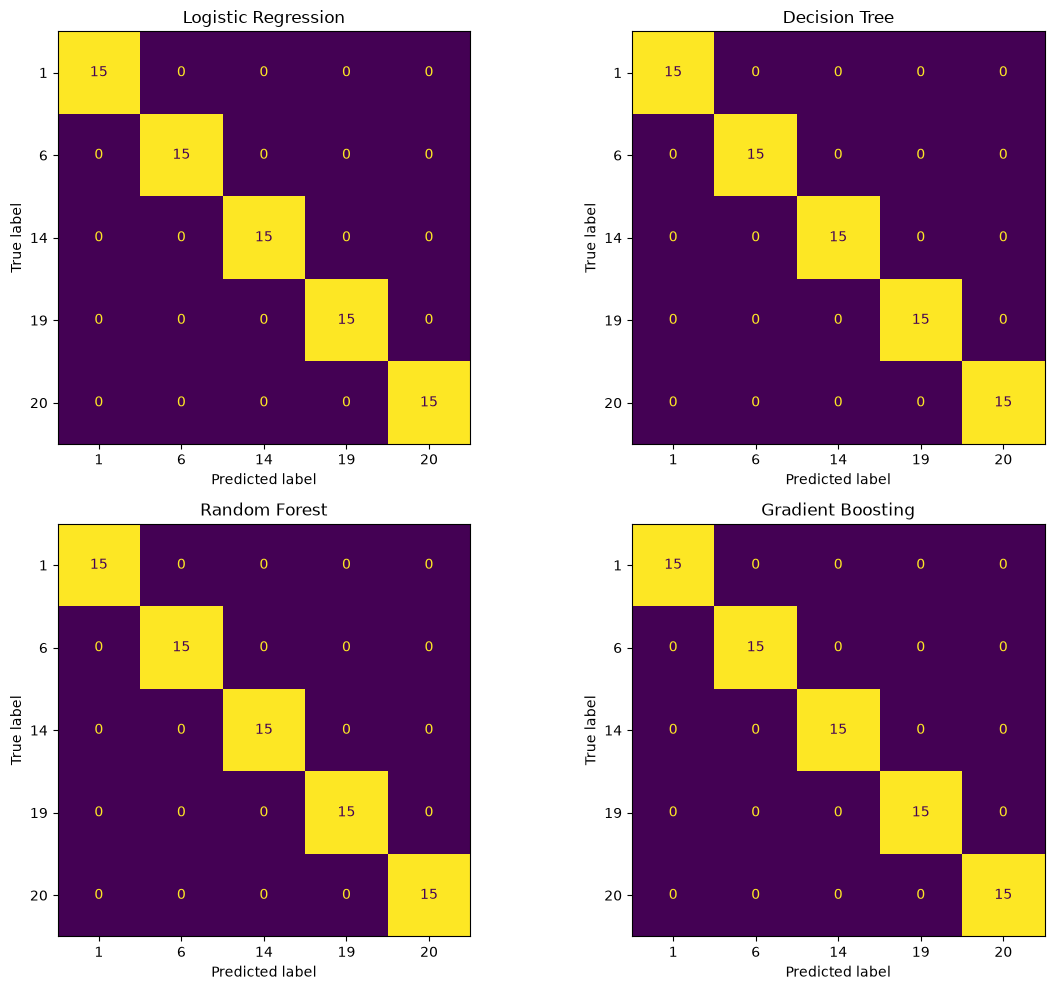

In [51]:
# Cell 45 — Confusion Matrices

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, predictions) in zip(
    axes.ravel(),
    model_predictions.items()
):
    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y_test.unique())
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

In [52]:
# Cell 46 — Feature Importance Comparison

feature_importance_comparison = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "Decision Tree": decision_tree.feature_importances_,
    "Random Forest": random_forest.feature_importances_,
    "Gradient Boosting": gradient_boosting.feature_importances_,
})

display(
    feature_importance_comparison.sort_values(
        by="Random Forest",
        ascending=False
    )
)

,feature,Decision Tree,Random Forest,Gradient Boosting
8,aspect_ratio,0.50,0.274453,5.774491e-01
7,bbox_height,0.25,0.225505,8.991489e-02
9,area_ratio,0.00,0.197709,1.331978e-01
6,bbox_width,0.25,0.152751,2.067342e-02
3,std_r,0.00,0.035911,6.616766e-02
0,mean_r,0.00,0.031016,1.797710e-02
5,std_b,0.00,0.030463,9.462003e-02
1,mean_g,0.00,0.019889,6.800923e-17
2,mean_b,0.00,0.018375,3.330034e-17
4,std_g,0.00,0.013929,-2.870260e-18


In [53]:
# Cell 47 — Logistic Regression Feature Influence

lr_feature_influence = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "mean_abs_coefficient": np.mean(
        np.abs(lr_coefficients.values),
        axis=0
    )
})

lr_feature_influence = lr_feature_influence.sort_values(
    by="mean_abs_coefficient",
    ascending=False
)

display(lr_feature_influence)

,feature,mean_abs_coefficient
1,mean_g,1.129553
5,std_b,0.897860
8,aspect_ratio,0.896110
7,bbox_height,0.879422
0,mean_r,0.821012
3,std_r,0.609267
9,area_ratio,0.597132
2,mean_b,0.543804
6,bbox_width,0.524813
4,std_g,0.424169


In [54]:
# Cell 48 — Multi-Scene Dataset Setup

MULTI_SCENE_IDS = [
    "000048", "000049", "000051", "000052",
    "000054", "000055", "000056", "000057",
    "000058", "000059"
]

print("Scenes selected for multi-scene evaluation:")
print(MULTI_SCENE_IDS)
print(f"\nNumber of scenes: {len(MULTI_SCENE_IDS)}")

Scenes selected for multi-scene evaluation:
['000048', '000049', '000051', '000052', '000054', '000055', '000056', '000057', '000058', '000059']

Number of scenes: 10


In [55]:
# Cell 49 — Extract Features from Multiple Scenes

all_scene_data = []

for scene_id in MULTI_SCENE_IDS:
    scene_path = TEST_DIR / scene_id

    rgb_dir = scene_path / "rgb"
    scene_gt_path = scene_path / "scene_gt.json"
    scene_gt_info_path = scene_path / "scene_gt_info.json"

    with open(scene_gt_path, "r") as f:
        scene_gt = __import__("json").load(f)

    with open(scene_gt_info_path, "r") as f:
        scene_gt_info = __import__("json").load(f)

    for frame_id, objects in scene_gt.items():
        frame_path = rgb_dir / f"{int(frame_id):06d}.png"

        if not frame_path.exists():
            continue

        image = np.array(Image.open(frame_path).convert("RGB"))
        image_height, image_width = image.shape[:2]

        for obj_idx, obj in enumerate(objects):
            obj_id = obj["obj_id"]
            info = scene_gt_info[frame_id][obj_idx]

            bbox = info["bbox_visib"]

            x, y, width, height = map(int, bbox)

            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(image_width, x + width)
            y2 = min(image_height, y + height)

            if x2 <= x1 or y2 <= y1:
                continue

            crop = image[y1:y2, x1:x2]

            all_scene_data.append({
                "scene_id": scene_id,
                "frame_id": int(frame_id),
                "obj_id": obj_id,

                "mean_r": crop[:, :, 0].mean(),
                "mean_g": crop[:, :, 1].mean(),
                "mean_b": crop[:, :, 2].mean(),

                "std_r": crop[:, :, 0].std(),
                "std_g": crop[:, :, 1].std(),
                "std_b": crop[:, :, 2].std(),

                "bbox_width": width,
                "bbox_height": height,

                "aspect_ratio": width / height if height > 0 else 0,
                "area_ratio": (width * height) / (image_width * image_height),
            })

multi_scene_df = pd.DataFrame(all_scene_data)

print("Multi-scene dataset shape:", multi_scene_df.shape)
print("\nScenes:")
print(sorted(multi_scene_df["scene_id"].unique()))

print("\nClass distribution:")
display(
    multi_scene_df["obj_id"]
    .value_counts()
    .sort_index()
)

Multi-scene dataset shape: (3525, 13)

Scenes:
['000048', '000049', '000051', '000052', '000054', '000055', '000056', '000057', '000058', '000059']

Class distribution:


obj_id
1     300
2     150
3     375
4     300
5      75
6     300
7      75
8      75
9     150
10     75
11    225
12    300
13     75
14    150
15    225
16     75
17     75
18    150
19    150
20    150
21     75
Name: count, dtype: int64

In [56]:
# Cell 50 — Scene-Level Train/Test Split

TEST_SCENE = "000048"

train_pool_df = multi_scene_df[
    multi_scene_df["scene_id"] != TEST_SCENE
].copy()

held_out_test_df = multi_scene_df[
    multi_scene_df["scene_id"] == TEST_SCENE
].copy()

print("Training pool shape:", train_pool_df.shape)
print("Held-out test shape:", held_out_test_df.shape)

print("\nTraining scenes:")
print(sorted(train_pool_df["scene_id"].unique()))

print("\nHeld-out test scene:")
print(sorted(held_out_test_df["scene_id"].unique()))

print("\nHeld-out test class distribution:")
display(
    held_out_test_df["obj_id"]
    .value_counts()
    .sort_index()
)

Training pool shape: (3150, 13)
Held-out test shape: (375, 13)

Training scenes:
['000049', '000051', '000052', '000054', '000055', '000056', '000057', '000058', '000059']

Held-out test scene:
['000048']

Held-out test class distribution:


obj_id
1     75
6     75
14    75
19    75
20    75
Name: count, dtype: int64

In [57]:
# Cell 51 — Scene-Level Train / Validation Split

VALIDATION_SCENE = "000059"

train_df = train_pool_df[
    train_pool_df["scene_id"] != VALIDATION_SCENE
].copy()

validation_df = train_pool_df[
    train_pool_df["scene_id"] == VALIDATION_SCENE
].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

print("\nTraining scenes:")
print(sorted(train_df["scene_id"].unique()))

print("\nValidation scene:")
print(sorted(validation_df["scene_id"].unique()))

print("\nValidation class distribution:")
display(
    validation_df["obj_id"]
    .value_counts()
    .sort_index()
)

Train shape: (2700, 13)
Validation shape: (450, 13)

Training scenes:
['000049', '000051', '000052', '000054', '000055', '000056', '000057', '000058']

Validation scene:
['000059']

Validation class distribution:


obj_id
2     75
4     75
6     75
9     75
15    75
18    75
Name: count, dtype: int64

In [58]:
# Cell 52 — Prepare Train, Validation, and Held-Out Test Sets

X_train_scene = train_df[FEATURE_COLUMNS]
y_train_scene = train_df[TARGET_COLUMN]

X_validation_scene = validation_df[FEATURE_COLUMNS]
y_validation_scene = validation_df[TARGET_COLUMN]

X_test_scene = held_out_test_df[FEATURE_COLUMNS]
y_test_scene = held_out_test_df[TARGET_COLUMN]

print("X_train:", X_train_scene.shape)
print("y_train:", y_train_scene.shape)

print("X_validation:", X_validation_scene.shape)
print("y_validation:", y_validation_scene.shape)

print("X_test:", X_test_scene.shape)
print("y_test:", y_test_scene.shape)

X_train: (2700, 10)
y_train: (2700,)
X_validation: (450, 10)
y_validation: (450,)
X_test: (375, 10)
y_test: (375,)


In [59]:
# Cell 53 — Scene-Level Logistic Regression

lr_scene = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_scene.fit(X_train_scene, y_train_scene)

lr_train_pred = lr_scene.predict(X_train_scene)
lr_validation_pred = lr_scene.predict(X_validation_scene)
lr_test_pred = lr_scene.predict(X_test_scene)

print("Logistic Regression — Scene-Level Evaluation")
print("-" * 45)
print(f"Train accuracy:      {accuracy_score(y_train_scene, lr_train_pred):.4f}")
print(f"Validation accuracy: {accuracy_score(y_validation_scene, lr_validation_pred):.4f}")
print(f"Held-out test accuracy: {accuracy_score(y_test_scene, lr_test_pred):.4f}")

Logistic Regression — Scene-Level Evaluation
---------------------------------------------
Train accuracy:      0.9822
Validation accuracy: 0.5111
Held-out test accuracy: 0.2427


In [60]:
# Cell 54 — Scene-Level Decision Tree

dt_scene = DecisionTreeClassifier(
    random_state=42
)

dt_scene.fit(X_train_scene, y_train_scene)

dt_train_pred = dt_scene.predict(X_train_scene)
dt_validation_pred = dt_scene.predict(X_validation_scene)
dt_test_pred = dt_scene.predict(X_test_scene)

print("Decision Tree — Scene-Level Evaluation")
print("-" * 45)
print(f"Train accuracy:         {accuracy_score(y_train_scene, dt_train_pred):.4f}")
print(f"Validation accuracy:    {accuracy_score(y_validation_scene, dt_validation_pred):.4f}")
print(f"Held-out test accuracy: {accuracy_score(y_test_scene, dt_test_pred):.4f}")

print(f"\nTree depth: {dt_scene.get_depth()}")
print(f"Number of leaves: {dt_scene.get_n_leaves()}")

Decision Tree — Scene-Level Evaluation
---------------------------------------------
Train accuracy:         1.0000
Validation accuracy:    0.4467
Held-out test accuracy: 0.2880

Tree depth: 15
Number of leaves: 79


In [61]:
# Cell 55 — Scene-Level Random Forest

rf_scene = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_scene.fit(X_train_scene, y_train_scene)

rf_train_pred = rf_scene.predict(X_train_scene)
rf_validation_pred = rf_scene.predict(X_validation_scene)
rf_test_pred = rf_scene.predict(X_test_scene)

print("Random Forest — Scene-Level Evaluation")
print("-" * 45)
print(f"Train accuracy:         {accuracy_score(y_train_scene, rf_train_pred):.4f}")
print(f"Validation accuracy:    {accuracy_score(y_validation_scene, rf_validation_pred):.4f}")
print(f"Held-out test accuracy: {accuracy_score(y_test_scene, rf_test_pred):.4f}")

print(f"\nNumber of trees: {len(rf_scene.estimators_)}")

Random Forest — Scene-Level Evaluation
---------------------------------------------
Train accuracy:         1.0000
Validation accuracy:    0.5444
Held-out test accuracy: 0.1973

Number of trees: 100


In [62]:
# Cell 56 — Scene-Level Gradient Boosting

gb_scene = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_scene.fit(X_train_scene, y_train_scene)

gb_train_pred = gb_scene.predict(X_train_scene)
gb_validation_pred = gb_scene.predict(X_validation_scene)
gb_test_pred = gb_scene.predict(X_test_scene)

print("Gradient Boosting — Scene-Level Evaluation")
print("-" * 45)
print(f"Train accuracy:         {accuracy_score(y_train_scene, gb_train_pred):.4f}")
print(f"Validation accuracy:    {accuracy_score(y_validation_scene, gb_validation_pred):.4f}")
print(f"Held-out test accuracy: {accuracy_score(y_test_scene, gb_test_pred):.4f}")

print(f"\nNumber of boosting stages: {gb_scene.n_estimators}")

Gradient Boosting — Scene-Level Evaluation
---------------------------------------------
Train accuracy:         1.0000
Validation accuracy:    0.3956
Held-out test accuracy: 0.2133

Number of boosting stages: 100


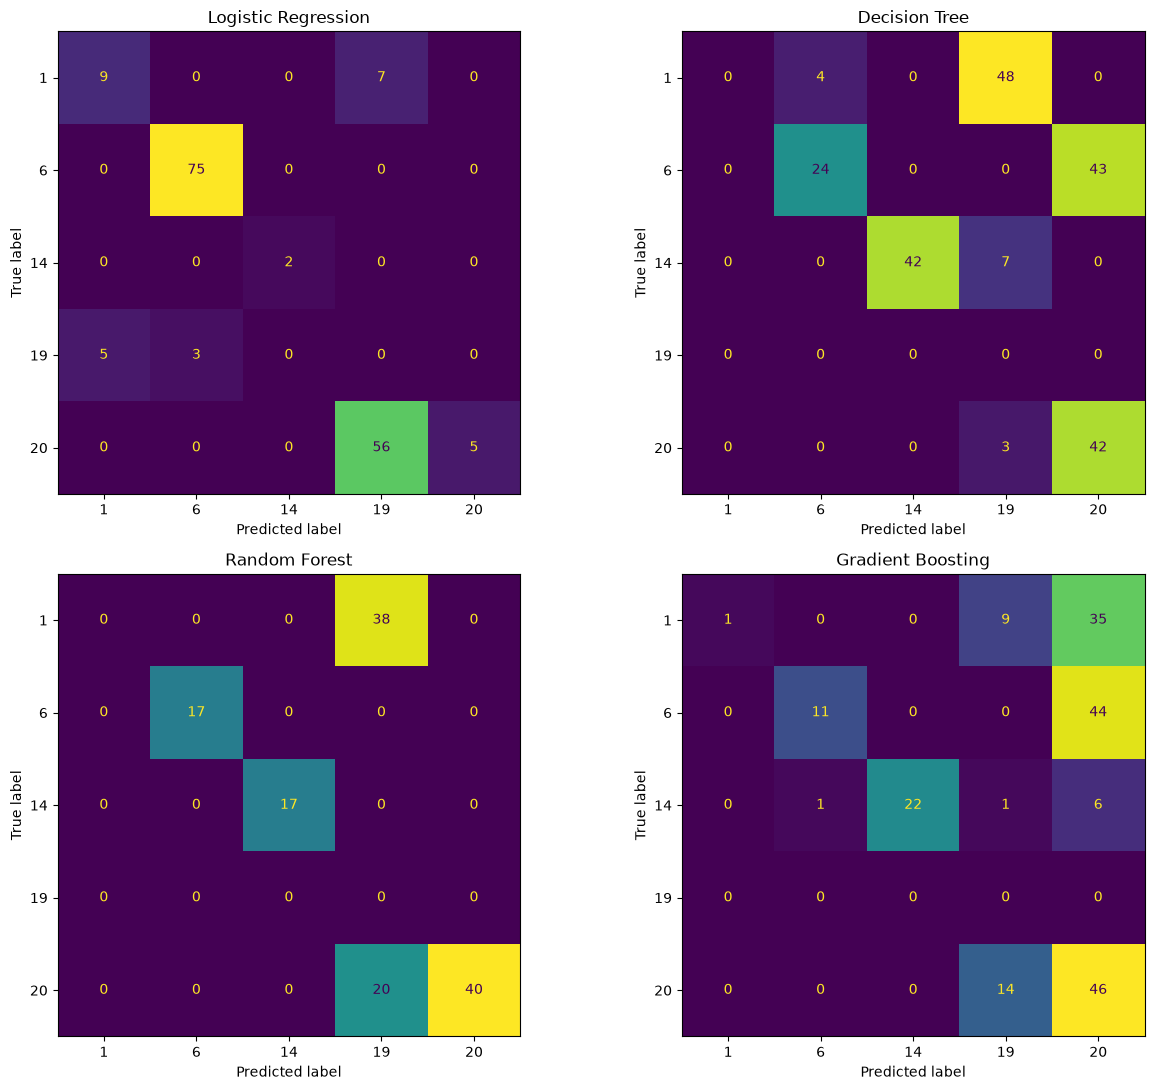

In [63]:
# Cell 57 — Held-Out Test Confusion Matrices

scene_model_predictions = {
    "Logistic Regression": lr_test_pred,
    "Decision Tree": dt_test_pred,
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_test_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, (model_name, predictions) in zip(
    axes.ravel(),
    scene_model_predictions.items()
):
    cm = confusion_matrix(
        y_test_scene,
        predictions,
        labels=sorted(y_test_scene.unique())
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(y_test_scene.unique())
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

In [64]:
# Cell 58 — Numeric Confusion Matrices

test_classes = sorted(y_test_scene.unique())

for model_name, predictions in scene_model_predictions.items():
    cm = confusion_matrix(
        y_test_scene,
        predictions,
        labels=test_classes
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual_{c}" for c in test_classes],
        columns=[f"Predicted_{c}" for c in test_classes]
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    display(cm_df)


Logistic Regression


,Predicted_1,Predicted_6,Predicted_14,Predicted_19,Predicted_20
Actual_1,9,0,0,7,0
Actual_6,0,75,0,0,0
Actual_14,0,0,2,0,0
Actual_19,5,3,0,0,0
Actual_20,0,0,0,56,5



Decision Tree


,Predicted_1,Predicted_6,Predicted_14,Predicted_19,Predicted_20
Actual_1,0,4,0,48,0
Actual_6,0,24,0,0,43
Actual_14,0,0,42,7,0
Actual_19,0,0,0,0,0
Actual_20,0,0,0,3,42



Random Forest


,Predicted_1,Predicted_6,Predicted_14,Predicted_19,Predicted_20
Actual_1,0,0,0,38,0
Actual_6,0,17,0,0,0
Actual_14,0,0,17,0,0
Actual_19,0,0,0,0,0
Actual_20,0,0,0,20,40



Gradient Boosting


,Predicted_1,Predicted_6,Predicted_14,Predicted_19,Predicted_20
Actual_1,1,0,0,9,35
Actual_6,0,11,0,0,44
Actual_14,0,1,22,1,6
Actual_19,0,0,0,0,0
Actual_20,0,0,0,14,46


In [65]:
# Cell 59 — All Predicted Classes on the Held-Out Test Scene

for model_name, predictions in scene_model_predictions.items():
    prediction_counts = pd.Series(predictions).value_counts().sort_index()

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print("Predicted class distribution:")
    display(
        prediction_counts
        .rename("count")
        .to_frame()
    )


Logistic Regression
Predicted class distribution:


,count
1,14
4,6
6,78
7,6
8,40
11,13
12,17
13,14
14,2
15,4



Decision Tree
Predicted class distribution:


,count
6,28
8,1
9,13
10,7
11,3
12,22
13,30
14,42
15,67
18,2



Random Forest
Predicted class distribution:


,count
4,12
6,17
8,27
12,12
13,15
14,17
15,68
18,27
19,58
20,40



Gradient Boosting
Predicted class distribution:


,count
1,1
3,4
4,40
6,12
8,25
12,29
14,22
15,45
16,4
18,26


In [66]:
# Cell 60 — Per-Class Failure Analysis

from collections import Counter

for model_name, predictions in scene_model_predictions.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    failure_rows = []

    for actual_class in sorted(y_test_scene.unique()):

        actual_mask = (y_test_scene == actual_class)
        actual_predictions = predictions[actual_mask]

        errors = actual_predictions[actual_predictions != actual_class]

        if len(errors) == 0:
            failure_rows.append({
                "actual_class": actual_class,
                "total_samples": len(actual_predictions),
                "errors": 0,
                "error_rate": 0.0,
                "most_common_wrong_prediction": None,
                "wrong_prediction_count": 0
            })
            continue

        wrong_counts = pd.Series(errors).value_counts()

        failure_rows.append({
            "actual_class": actual_class,
            "total_samples": len(actual_predictions),
            "errors": len(errors),
            "error_rate": len(errors) / len(actual_predictions),
            "most_common_wrong_prediction": wrong_counts.index[0],
            "wrong_prediction_count": wrong_counts.iloc[0]
        })

    failure_df = pd.DataFrame(failure_rows)

    display(failure_df)


Logistic Regression


,actual_class,total_samples,errors,error_rate,most_common_wrong_prediction,wrong_prediction_count
0,1,75,66,0.880000,21.0,53
1,6,75,0,0.000000,NaN,0
2,14,75,73,0.973333,8.0,40
3,19,75,75,1.000000,18.0,30
4,20,75,70,0.933333,19.0,56



Decision Tree


,actual_class,total_samples,errors,error_rate,most_common_wrong_prediction,wrong_prediction_count
0,1,75,75,1.00,19,48
1,6,75,51,0.68,20,43
2,14,75,33,0.44,9,13
3,19,75,75,1.00,15,53
4,20,75,33,0.44,13,30



Random Forest


,actual_class,total_samples,errors,error_rate,most_common_wrong_prediction,wrong_prediction_count
0,1,75,75,1.000000,19,38
1,6,75,58,0.773333,21,44
2,14,75,58,0.773333,21,31
3,19,75,75,1.000000,15,51
4,20,75,35,0.466667,19,20



Gradient Boosting


,actual_class,total_samples,errors,error_rate,most_common_wrong_prediction,wrong_prediction_count
0,1,75,74,0.986667,20,35
1,6,75,64,0.853333,20,44
2,14,75,53,0.706667,8,25
3,19,75,75,1.000000,12,29
4,20,75,29,0.386667,19,14


In [68]:
# Cell 61A — Import Classification Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [70]:
# Cell 61 — Scene-Level Test Metrics

scene_test_metrics = []

for model_name, predictions in scene_model_predictions.items():

    scene_test_metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_scene, predictions),
        "Macro Precision": precision_score(
            y_test_scene,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test_scene,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test_scene,
            predictions,
            average="macro",
            zero_division=0
        )
    })

scene_test_metrics_df = pd.DataFrame(scene_test_metrics)

display(
    scene_test_metrics_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.2427,0.2575,0.0867,0.0971
1,Decision Tree,0.2880,0.1679,0.1029,0.1221
2,Random Forest,0.1973,0.2500,0.0822,0.1196
3,Gradient Boosting,0.2133,0.2514,0.0821,0.0907


In [71]:

# Cell 62 — Feature Importance on the Scene-Level Training Set

tree_models = {

    "Decision Tree": dt_scene,

    "Random Forest": rf_scene,

    "Gradient Boosting": gb_scene

}

scene_feature_importance = pd.DataFrame({

    "Feature": FEATURE_COLUMNS

})

for model_name, model in tree_models.items():

    scene_feature_importance[model_name] = model.feature_importances_

scene_feature_importance["Mean Importance"] = (

    scene_feature_importance[

        ["Decision Tree", "Random Forest", "Gradient Boosting"]

    ].mean(axis=1)

)

scene_feature_importance = scene_feature_importance.sort_values(

    "Mean Importance",

    ascending=False

).reset_index(drop=True)

display(

    scene_feature_importance.style.format({

        "Decision Tree": "{:.4f}",

        "Random Forest": "{:.4f}",

        "Gradient Boosting": "{:.4f}",

        "Mean Importance": "{:.4f}"

    })

)


,Feature,Decision Tree,Random Forest,Gradient Boosting,Mean Importance
0,aspect_ratio,0.1668,0.1457,0.1808,0.1644
1,area_ratio,0.1745,0.1393,0.1388,0.1509
2,bbox_height,0.1261,0.1277,0.1239,0.1259
3,mean_r,0.1024,0.1091,0.1213,0.1109
4,mean_b,0.1422,0.0985,0.0806,0.1071
5,mean_g,0.0578,0.1067,0.1197,0.0948
6,std_r,0.0839,0.0808,0.0759,0.0802
7,bbox_width,0.0594,0.0848,0.0679,0.0707
8,std_b,0.0585,0.0539,0.0568,0.0564
9,std_g,0.0284,0.0535,0.0342,0.0387


In [74]:
# Cell 63 — Final Scene-Level Model Comparison

final_scene_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train Accuracy": [
        accuracy_score(y_train_scene, lr_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, dt_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, rf_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, gb_scene.predict(X_train_scene))
    ],
    "Validation Accuracy": [
        accuracy_score(y_val_scene, lr_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, dt_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, rf_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, gb_scene.predict(X_val_scene))
    ],
    "Held-out Test Accuracy": [
        accuracy_score(y_test_scene, scene_model_predictions["Logistic Regression"]),
        accuracy_score(y_test_scene, scene_model_predictions["Decision Tree"]),
        accuracy_score(y_test_scene, scene_model_predictions["Random Forest"]),
        accuracy_score(y_test_scene, scene_model_predictions["Gradient Boosting"])
    ],
    "Macro Precision": scene_test_metrics_df["Macro Precision"].values,
    "Macro Recall": scene_test_metrics_df["Macro Recall"].values,
    "Macro F1": scene_test_metrics_df["Macro F1"].values
})

display(
    final_scene_comparison.style.format({
        "Train Accuracy": "{:.4f}",
        "Validation Accuracy": "{:.4f}",
        "Held-out Test Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)


,Model,Train Accuracy,Validation Accuracy,Held-out Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.9822,0.5111,0.2427,0.2575,0.0867,0.0971
1,Decision Tree,1.0000,0.4467,0.2880,0.1679,0.1029,0.1221
2,Random Forest,1.0000,0.5444,0.1973,0.2500,0.0822,0.1196
3,Gradient Boosting,1.0000,0.3956,0.2133,0.2514,0.0821,0.0907


In [73]:
# Cell 64 — Rebuild Scene-Level Train / Validation / Test Splits

TRAIN_SCENES = [
    "000049", "000051", "000052", "000054",
    "000055", "000056", "000057", "000058"
]

VAL_SCENE = "000059"
TEST_SCENE = "000048"

# Training data
train_scene_df = multi_scene_df[
    multi_scene_df["scene_id"].isin(TRAIN_SCENES)
].copy()

# Validation data
val_scene_df = multi_scene_df[
    multi_scene_df["scene_id"] == VAL_SCENE
].copy()

# Completely unseen test scene
test_scene_df = multi_scene_df[
    multi_scene_df["scene_id"] == TEST_SCENE
].copy()

# Features and target
X_train_scene = train_scene_df[FEATURE_COLUMNS]
y_train_scene = train_scene_df[TARGET_COLUMN]

X_val_scene = val_scene_df[FEATURE_COLUMNS]
y_val_scene = val_scene_df[TARGET_COLUMN]

X_test_scene = test_scene_df[FEATURE_COLUMNS]
y_test_scene = test_scene_df[TARGET_COLUMN]

print("Train:", X_train_scene.shape, y_train_scene.shape)
print("Validation:", X_val_scene.shape, y_val_scene.shape)
print("Held-out test:", X_test_scene.shape, y_test_scene.shape)

print("\nValidation classes:")
print(sorted(y_val_scene.unique()))

print("\nTest classes:")
print(sorted(y_test_scene.unique()))

Train: (2700, 10) (2700,)
Validation: (450, 10) (450,)
Held-out test: (375, 10) (375,)

Validation classes:
[np.int64(2), np.int64(4), np.int64(6), np.int64(9), np.int64(15), np.int64(18)]

Test classes:
[np.int64(1), np.int64(6), np.int64(14), np.int64(19), np.int64(20)]


In [75]:
# Cell 65 — Final Scene-Level Model Comparison

final_scene_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train Accuracy": [
        accuracy_score(y_train_scene, lr_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, dt_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, rf_scene.predict(X_train_scene)),
        accuracy_score(y_train_scene, gb_scene.predict(X_train_scene))
    ],
    "Validation Accuracy": [
        accuracy_score(y_val_scene, lr_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, dt_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, rf_scene.predict(X_val_scene)),
        accuracy_score(y_val_scene, gb_scene.predict(X_val_scene))
    ],
    "Held-out Test Accuracy": [
        accuracy_score(y_test_scene, scene_model_predictions["Logistic Regression"]),
        accuracy_score(y_test_scene, scene_model_predictions["Decision Tree"]),
        accuracy_score(y_test_scene, scene_model_predictions["Random Forest"]),
        accuracy_score(y_test_scene, scene_model_predictions["Gradient Boosting"])
    ],
    "Macro Precision": scene_test_metrics_df["Macro Precision"].values,
    "Macro Recall": scene_test_metrics_df["Macro Recall"].values,
    "Macro F1": scene_test_metrics_df["Macro F1"].values
})

display(
    final_scene_comparison.style.format({
        "Train Accuracy": "{:.4f}",
        "Validation Accuracy": "{:.4f}",
        "Held-out Test Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
) 

,Model,Train Accuracy,Validation Accuracy,Held-out Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.9822,0.5111,0.2427,0.2575,0.0867,0.0971
1,Decision Tree,1.0000,0.4467,0.2880,0.1679,0.1029,0.1221
2,Random Forest,1.0000,0.5444,0.1973,0.2500,0.0822,0.1196
3,Gradient Boosting,1.0000,0.3956,0.2133,0.2514,0.0821,0.0907


In [76]:
# Cell 66 — Corrected Metrics for Held-out Test Classes

TEST_CLASSES = sorted(y_test_scene.unique())

corrected_metrics = []

for model_name, predictions in scene_model_predictions.items():
    corrected_metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_scene,
            predictions
        ),
        "Macro Precision": precision_score(
            y_test_scene,
            predictions,
            labels=TEST_CLASSES,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test_scene,
            predictions,
            labels=TEST_CLASSES,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test_scene,
            predictions,
            labels=TEST_CLASSES,
            average="macro",
            zero_division=0
        )
    })

corrected_metrics_df = pd.DataFrame(corrected_metrics)

display(
    corrected_metrics_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.2427,0.7209,0.2427,0.2719
1,Decision Tree,0.2880,0.4703,0.2880,0.3418
2,Random Forest,0.1973,0.6000,0.1973,0.2870
3,Gradient Boosting,0.2133,0.6536,0.2133,0.2359


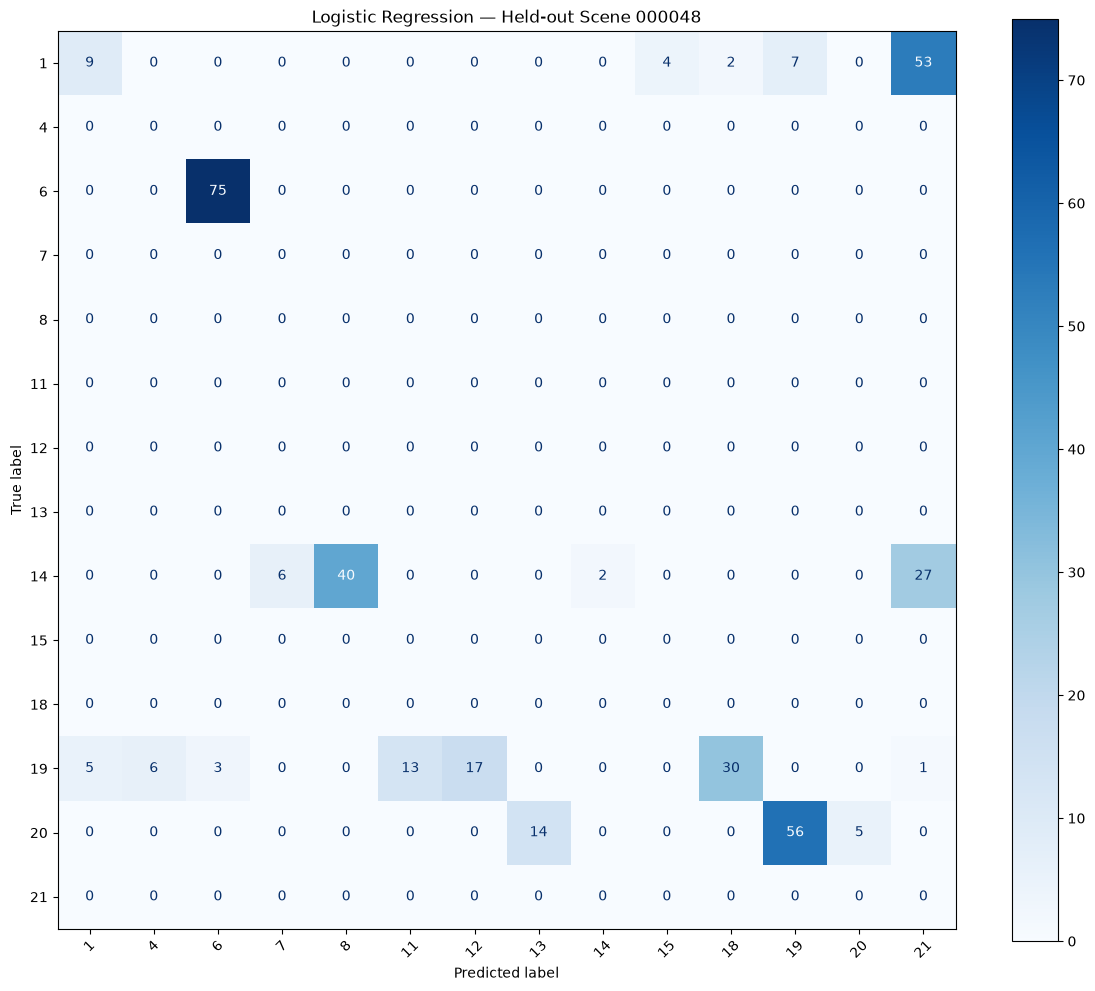

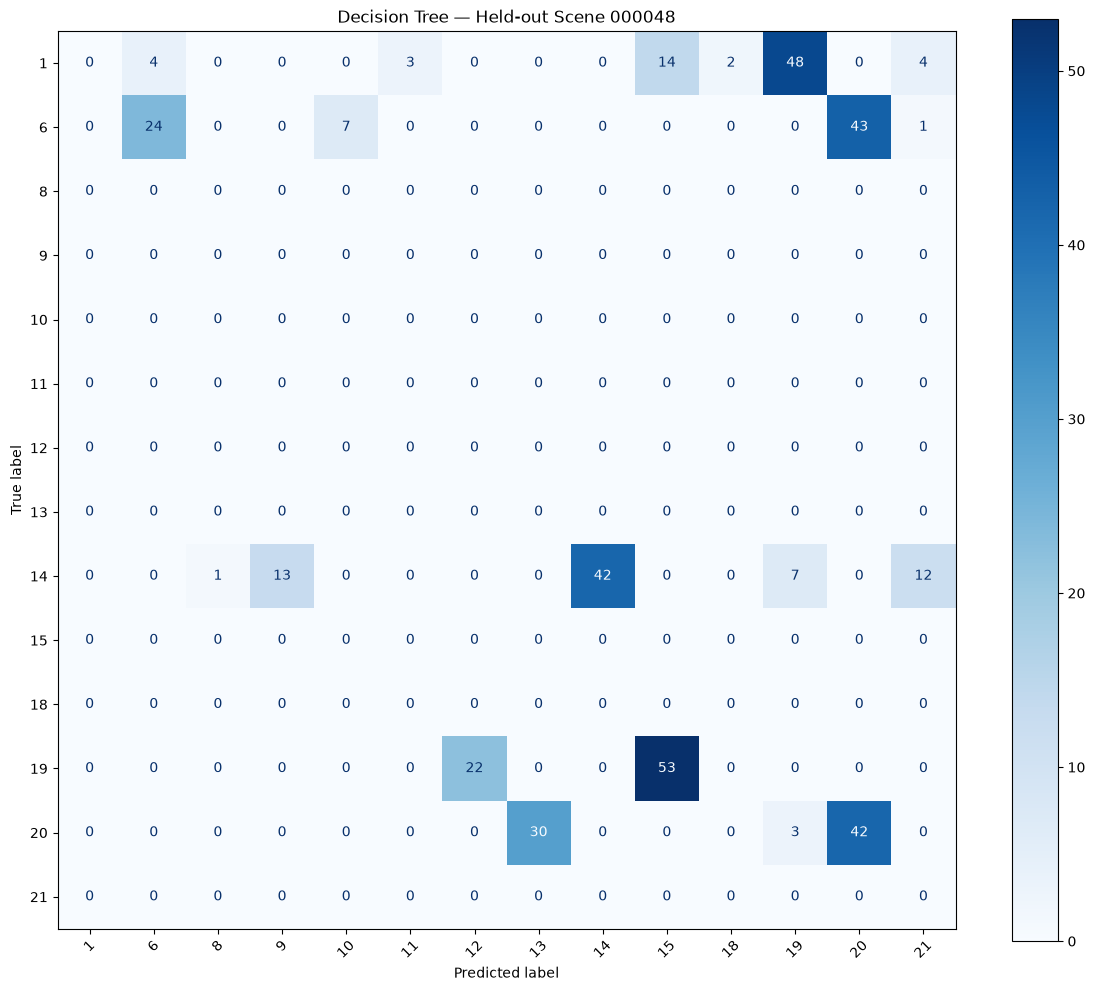

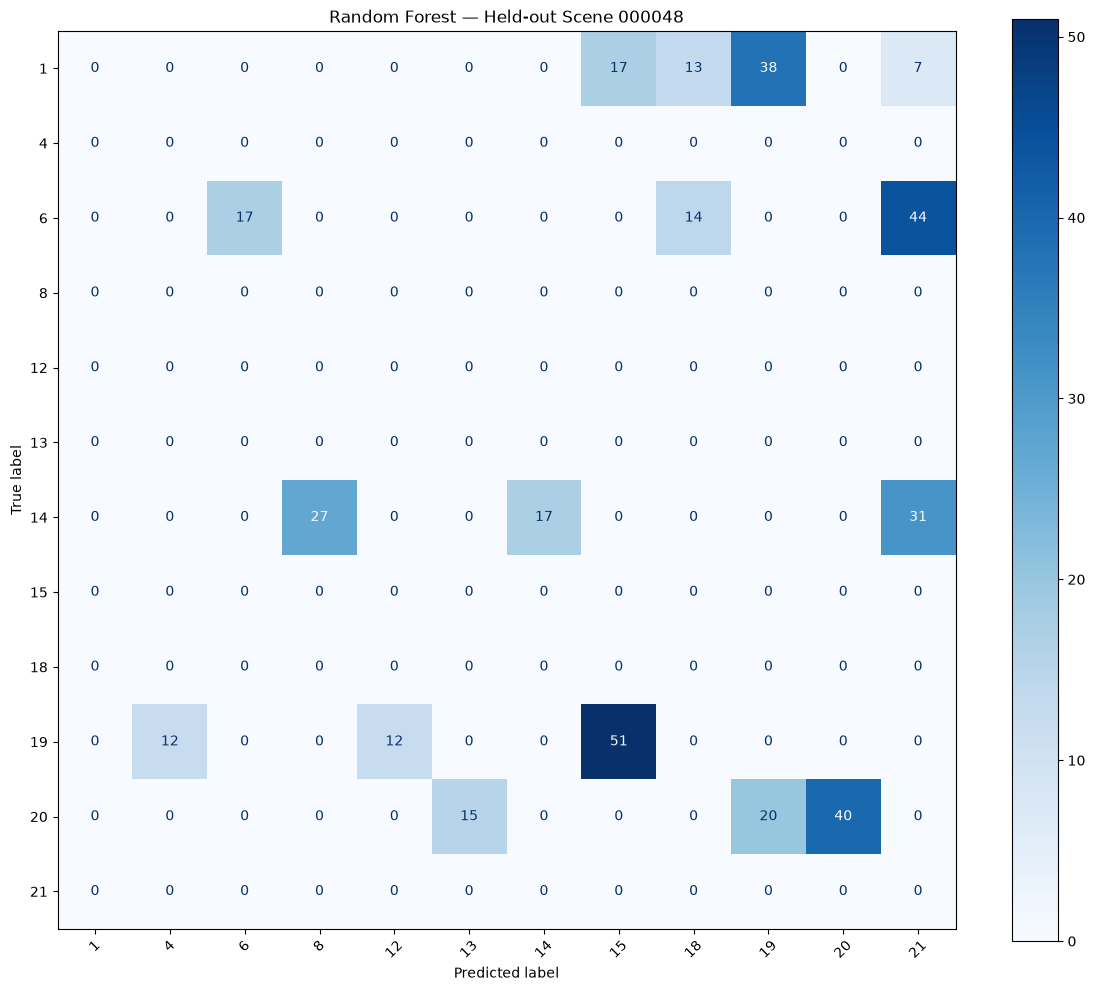

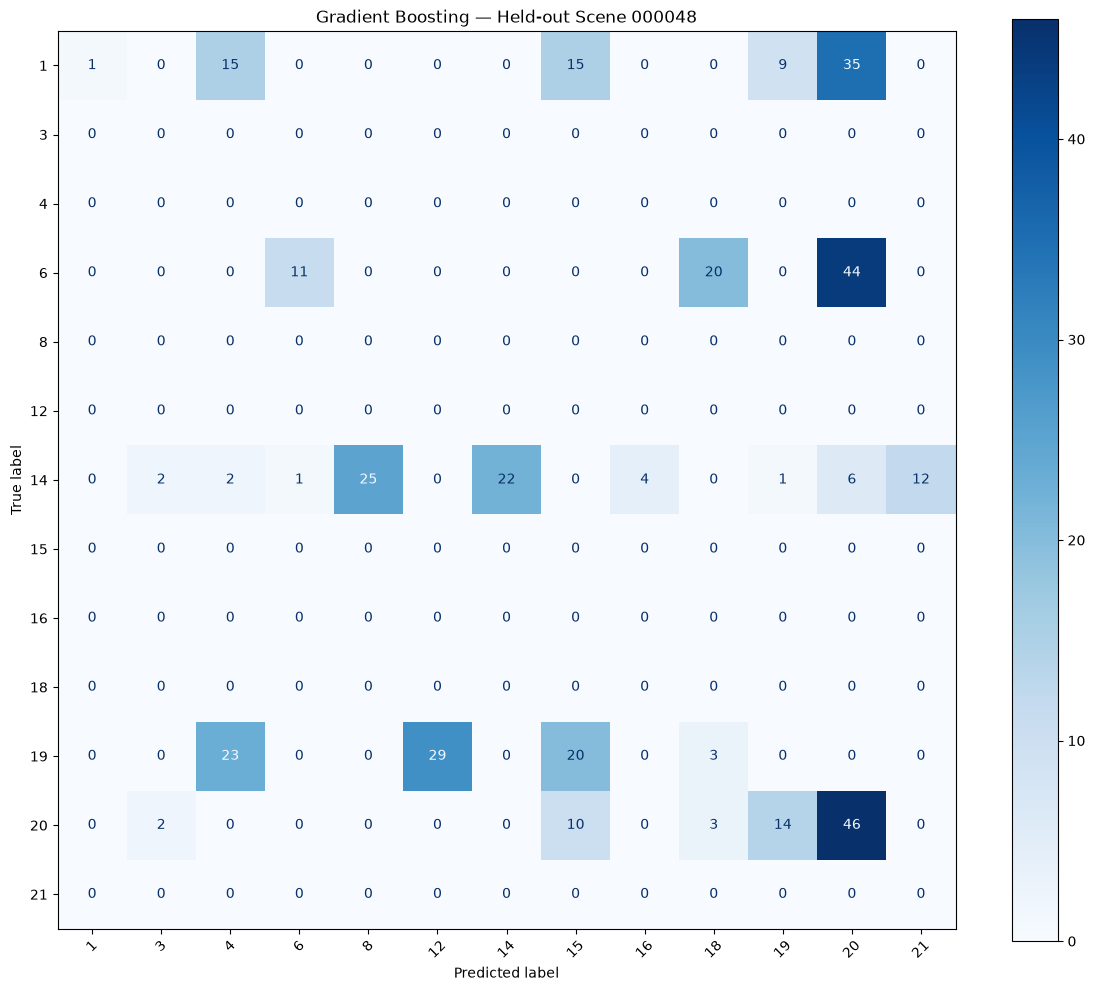

In [77]:
# Cell 67 — Confusion Matrices for Held-out Test Scene

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, predictions in scene_model_predictions.items():
    
    labels = sorted(
        set(y_test_scene.unique()) | set(predictions)
    )
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test_scene,
        predictions,
        labels=labels,
        display_labels=labels,
        cmap="Blues",
        xticks_rotation=45,
        ax=ax
    )
    
    ax.set_title(
        f"{model_name} — Held-out Scene 000048"
    )
    
    plt.tight_layout()
    plt.show()

In [79]:
# Cell 68 — Per-Class Failure Analysis

failure_analysis = []

test_classes = sorted(y_test_scene.unique())

for model_name, predictions in scene_model_predictions.items():

    for class_id in test_classes:

        # Samples belonging to this actual class
        class_mask = (y_test_scene == class_id)

        actual_count = class_mask.sum()

        # Predictions for this actual class
        class_predictions = predictions[class_mask]

        correct_count = (class_predictions == class_id).sum()

        error_count = actual_count - correct_count
        error_rate = error_count / actual_count

        # Find the most common incorrect prediction
        wrong_predictions = class_predictions[
            class_predictions != class_id
        ]

        if len(wrong_predictions) > 0:

            unique_predictions, counts = np.unique(
                wrong_predictions,
                return_counts=True
            )

            most_common_index = np.argmax(counts)

            most_common_wrong = unique_predictions[most_common_index]
            most_common_wrong_count = counts[most_common_index]

        else:
            most_common_wrong = None
            most_common_wrong_count = 0

        failure_analysis.append({
            "Model": model_name,
            "Class": class_id,
            "Total Samples": actual_count,
            "Correct": correct_count,
            "Errors": error_count,
            "Error Rate": error_rate,
            "Most Common Wrong Prediction": most_common_wrong,
            "Wrong Prediction Count": most_common_wrong_count
        })

failure_analysis_df = pd.DataFrame(failure_analysis)

display(
    failure_analysis_df.style.format({
        "Error Rate": "{:.2%}"
    })
)

,Model,Class,Total Samples,Correct,Errors,Error Rate,Most Common Wrong Prediction,Wrong Prediction Count
0,Logistic Regression,1,75,9,66,88.00%,21.000000,53
1,Logistic Regression,6,75,75,0,0.00%,nan,0
2,Logistic Regression,14,75,2,73,97.33%,8.000000,40
3,Logistic Regression,19,75,0,75,100.00%,18.000000,30
4,Logistic Regression,20,75,5,70,93.33%,19.000000,56
5,Decision Tree,1,75,0,75,100.00%,19.000000,48
6,Decision Tree,6,75,24,51,68.00%,20.000000,43
7,Decision Tree,14,75,42,33,44.00%,9.000000,13
8,Decision Tree,19,75,0,75,100.00%,15.000000,53
9,Decision Tree,20,75,42,33,44.00%,13.000000,30


In [80]:
# Cell 69 — Random Split vs Scene-Level Generalization

generalization_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Random Split Test Accuracy": [
        1.00,
        1.00,
        1.00,
        1.00
    ],
    "Scene-Level Test Accuracy": [
        0.2427,
        0.2880,
        0.1973,
        0.2133
    ]
})

generalization_comparison["Accuracy Drop"] = (
    generalization_comparison["Random Split Test Accuracy"]
    - generalization_comparison["Scene-Level Test Accuracy"]
)

display(
    generalization_comparison.style.format({
        "Random Split Test Accuracy": "{:.2%}",
        "Scene-Level Test Accuracy": "{:.2%}",
        "Accuracy Drop": "{:.2%}"
    })
)

,Model,Random Split Test Accuracy,Scene-Level Test Accuracy,Accuracy Drop
0,Logistic Regression,100.00%,24.27%,75.73%
1,Decision Tree,100.00%,28.80%,71.20%
2,Random Forest,100.00%,19.73%,80.27%
3,Gradient Boosting,100.00%,21.33%,78.67%


In [81]:
# Cell 70 — Model Strengths & Weaknesses

model_analysis = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Strengths": [
        "Simple, fast, interpretable linear baseline",
        "Highly interpretable rules; captures nonlinear boundaries",
        "Reduces variance through bagging and feature randomness",
        "Captures nonlinear relationships through sequential boosting"
    ],
    
    "Weaknesses": [
        "Limited by linear decision boundaries",
        "Can overfit; sensitive to scene-specific patterns",
        "More complex and less interpretable; did not generalize well here",
        "More complex; sensitive to scene-specific patterns and hyperparameters"
    ],
    
    "Observed_Random_Split": [
        "100% accuracy",
        "100% accuracy",
        "100% accuracy",
        "100% accuracy"
    ],
    
    "Observed_Scene_Level": [
        "24.27% test accuracy",
        "28.80% test accuracy",
        "19.73% test accuracy",
        "21.33% test accuracy"
    ]
})

display(model_analysis)

,Model,Strengths,Weaknesses,Observed_Random_Split,Observed_Scene_Level
0,Logistic Regression,"Simple, fast, interpretable linear baseline",Limited by linear decision boundaries,100% accuracy,24.27% test accuracy
1,Decision Tree,Highly interpretable rules; captures nonlinear...,Can overfit; sensitive to scene-specific patterns,100% accuracy,28.80% test accuracy
2,Random Forest,Reduces variance through bagging and feature r...,More complex and less interpretable; did not g...,100% accuracy,19.73% test accuracy
3,Gradient Boosting,Captures nonlinear relationships through seque...,More complex; sensitive to scene-specific patt...,100% accuracy,21.33% test accuracy


In [82]:
# Cell 71 — Final Model Comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Random Split Accuracy": [
        1.0000,
        1.0000,
        1.0000,
        1.0000
    ],
    
    "Scene-Level Test Accuracy": [
        0.2427,
        0.2880,
        0.1973,
        0.2133
    ],
    
    "Scene-Level Macro F1": [
        0.0971,
        0.1221,
        0.1196,
        0.0907
    ],
    
    "Generalization Drop": [
        0.7573,
        0.7120,
        0.8027,
        0.7867
    ]
})

display(
    final_comparison.style.format({
        "Random Split Accuracy": "{:.2%}",
        "Scene-Level Test Accuracy": "{:.2%}",
        "Scene-Level Macro F1": "{:.4f}",
        "Generalization Drop": "{:.2%}"
    })
)

,Model,Random Split Accuracy,Scene-Level Test Accuracy,Scene-Level Macro F1,Generalization Drop
0,Logistic Regression,100.00%,24.27%,0.0971,75.73%
1,Decision Tree,100.00%,28.80%,0.1221,71.20%
2,Random Forest,100.00%,19.73%,0.1196,80.27%
3,Gradient Boosting,100.00%,21.33%,0.0907,78.67%


In [83]:
# Cell 72 — Limitations & Generalization

limitations = pd.DataFrame({
    "Limitation": [
        "Random frame splitting",
        "Single held-out test scene",
        "Single validation scene",
        "Simple handcrafted features",
        "Bounding-box based RGB statistics",
        "Different class composition across scenes"
    ],
    
    "Impact": [
        "Can place visually similar frames from the same scene in both train and test, producing overly optimistic results.",
        "Results may depend strongly on the characteristics of scene 000048.",
        "Validation performance may not represent general performance across unseen scenes.",
        "Mean/std RGB and bounding-box geometry may not capture enough object-specific information.",
        "RGB statistics can include background pixels inside the bounding box, reducing robustness to scene changes.",
        "Some object classes appear in the training and validation scenes but not in the held-out test scene, making cross-scene classification more difficult."
    ]
})

display(limitations)

,Limitation,Impact
0,Random frame splitting,Can place visually similar frames from the sam...
1,Single held-out test scene,Results may depend strongly on the characteris...
2,Single validation scene,Validation performance may not represent gener...
3,Simple handcrafted features,Mean/std RGB and bounding-box geometry may not...
4,Bounding-box based RGB statistics,RGB statistics can include background pixels i...
5,Different class composition across scenes,Some object classes appear in the training and...


In [84]:
# Cell 73 — Experiment Summary

experiment_summary = pd.DataFrame({
    "Experiment": [
        "Random frame split",
        "Scene-level evaluation",
        "Held-out test scene",
        "Validation scene",
        "Number of models",
        "Number of input features",
        "Number of classes"
    ],
    
    "Result": [
        "All four models achieved 100% test accuracy",
        "All four models showed substantial performance degradation",
        "Scene 000048",
        "Scene 000059",
        "4",
        "10",
        "21"
    ]
})

display(experiment_summary)

,Experiment,Result
0,Random frame split,All four models achieved 100% test accuracy
1,Scene-level evaluation,All four models showed substantial performance...
2,Held-out test scene,Scene 000048
3,Validation scene,Scene 000059
4,Number of models,4
5,Number of input features,10
6,Number of classes,21
